In [1]:
import requests
import pandas as pd

 ##  Engagement data (GitHub API)

In [2]:
import requests
import pandas as pd

repos = ["supabase/supabase", "appwrite/appwrite", "firebase/firebase-js-sdk"]

rows = []
for repo in repos:
    r = requests.get(f"https://api.github.com/repos/{repo}", timeout=15)
    if r.status_code != 200:
        print(repo, "error", r.status_code)
        continue
    d = r.json()
    rows.append({
        "product": repo.split("/")[0],
        "stars": d["stargazers_count"],
        "forks": d["forks_count"],
        "open_issues": d["open_issues_count"],
    })

df_github = pd.DataFrame(rows)
df_github

,product,stars,forks,open_issues
0,supabase,111040,15579,1133
1,appwrite,57553,5756,686
2,firebase,5146,1038,731


In [3]:
from datetime import date

df_github["source"] = "GitHub API"
df_github["date_collected"] = date.today().isoformat()

df_github.to_csv("github_engagement.csv", index=False)
df_github

,product,stars,forks,open_issues,source,date_collected
0,supabase,111040,15579,1133,GitHub API,2026-10-03
1,appwrite,57553,5756,686,GitHub API,2026-10-03
2,firebase,5146,1038,731,GitHub API,2026-10-03


In [4]:
import requests

headers = {"User-Agent": "Mozilla/5.0"}
urls = {
    "supabase": "https://supabase.com/pricing",
    "appwrite": "https://appwrite.io/pricing",
    "firebase": "https://firebase.google.com/pricing",
}

## Robots.txt check
I downloaded each site's robots.txt file with a browser-like User-Agent. Appwrite's server blocked Python's default request with a 403 error, which made the default checker wrongly report "not allowed". The real rules allow the pricing page..

##  Pricing pages: robots.txt check and download

In [5]:
import urllib.robotparser
from urllib.parse import urlparse

for name, url in urls.items():
    p = urlparse(url)
    r = requests.get(f"{p.scheme}://{p.netloc}/robots.txt", headers=headers, timeout=15)
    rp = urllib.robotparser.RobotFileParser()
    rp.parse(r.text.splitlines())
    print(name, "| robots.txt status:", r.status_code, "| allowed:", rp.can_fetch("*", url))
    

supabase | robots.txt status: 200 | allowed: True
appwrite | robots.txt status: 200 | allowed: True
firebase | robots.txt status: 200 | allowed: True


In [6]:
import re
from bs4 import BeautifulSoup

pages_text = {}

for name, url in urls.items():
    resp = requests.get(url, headers=headers, timeout=15)
    soup = BeautifulSoup(resp.text, "html.parser")
    for tag in soup(["script", "style"]):
        tag.decompose()
    text = soup.get_text(" ", strip=True)
    pages_text[name] = text

    matches = list(re.finditer(r"\$\d[\d,.]*", text))
    print(f"\n{name}: {len(matches)} dollar prices found")
    for m in matches[:6]:
        print("   ...", text[max(0, m.start() - 50): m.end() + 40], "...")


supabase: 92 dollar prices found
   ...  First project included. Additional projects from $10/mo. See how pricing scales Everything i ...
   ... ree Plan, plus: 100,000 monthly active users then $0.00325 per MAU 8 GB disk size per project then ...
   ...  $0.00325 per MAU 8 GB disk size per project then $0.125 per GB 250 GB egress then $0.09 per GB  ...
   ... per project then $0.125 per GB 250 GB egress then $0.09 per GB 250 GB cached egress then $0.03  ...
   ... gress then $0.09 per GB 250 GB cached egress then $0.03 per GB 100 GB file storage then $0.0213 ...
   ... egress then $0.03 per GB 100 GB file storage then $0.0213 per GB Email support Daily backups stor ...

appwrite: 11 dollar prices found
   ... table costs. Serverless Dedicated Monthly compute $0 fixed fee From $10/mo per database Read ...
   ... rless Dedicated Monthly compute $0 fixed fee From $10/mo per database Reads and writes Plan q ...
   ... ectorsDB,
PostgreSQL, MySQL,
or upgraded TablesDB $10 of compute credi

In [7]:
for name, text in pages_text.items():
    print("\n=====", name, "=====")
    hits = [m.start() for m in re.finditer(r"/mo|per month|/month", text)]
    for pos in hits[:12]:
        print("...", text[max(0, pos - 90): pos + 60], "...")


===== supabase =====
...  scale. Get Started From $ 25 / month First project included. Additional projects from $10/mo. See how pricing scales Everything in the Free Plan, plu ...
... tions. Get Started From $ 599 / month First project included. Additional projects from $10/mo. See how pricing scales Everything in the Pro Plan, plus ...
... ee your total cost What is “compute”? About compute 1. Choose your plan Pro Team Pro $ 25 /month Everything in the Free Plan, plus: 100K monthly activ ...
... ject 250 GB bandwidth Daily backups (7 day retention) Email support Paid plans include $10/mo in compute credits, enough to cover one Micro instance.  ...
... GB RAM / Shared compute / Connections: Direct 60 , Pooler 200 Add Project Starts from $10 /month Scale compute up to 64 vCPUs and 256 GB RAM Learn abo ...
... nces are billed hourly and you can scale up or down at any time. Paid Plans come with $10 /month in compute credits to cover one Micro instance or off ...
... h off the spend cap 

##  Plan fees and usage prices

In [8]:
import pandas as pd
from datetime import date

today = date.today().isoformat()

# ---- Plan fees ----
plans = pd.DataFrame([
    ["supabase", "Free", 0, "Fixed plan fee", "supabase.com/pricing"],
    ["supabase", "Pro", 25, "Fixed plan fee + usage", "supabase.com/pricing"],
    ["supabase", "Team", 599, "Fixed plan fee + usage ('from' price)", "supabase.com/pricing"],
    ["firebase", "No-cost (Spark)", 0, "Free with fixed limits", "firebase.google.com/pricing"],
    ["firebase", "Pay as you go (Blaze)", 0, "No fixed fee, pay for usage", "firebase.google.com/pricing"],
    ["appwrite", "Free", 0, "Free with fixed limits", "appwrite.io/pricing"],
    ["appwrite", "Pro", 25, "Fixed plan fee ('from' price) + pay as you go", "appwrite.io/pricing"],
], columns=["product", "plan", "monthly_fee_usd", "pricing_model", "source"])
plans["date_collected"] = today

# ---- Usage prices ----
usage = pd.DataFrame([
    ["supabase", "File storage", "100 GB (Pro)", 0.0213, "per GB"],
    ["firebase", "File storage (Cloud Storage, legacy buckets)", "5 GB (Blaze plan)", 0.026, "per GB"],
    ["appwrite", "File storage", "150 GB (Pro)", 2.8 / 100, "per GB"],
    ["supabase", "Data transfer out", "250 GB (Pro)", 0.09, "per GB"],
    ["firebase", "Data transfer out (Cloud Storage downloads)", "1 GB/day (Blaze plan)", 0.12, "per GB"],
    ["appwrite", "Data transfer out (API bandwidth)", "2 TB (Pro)", 15 / 100, "per GB"],
    ["supabase", "Active users (MAU)", "100,000 (Pro)", 0.00325, "per user"],
    ["firebase", "Active users (Authentication)", "50,000 (some features)", None, "price not shown on page"],
    ["appwrite", "Active users (MAU)", "200,000 (Pro)", None, "price not shown on page"],
], columns=["product", "item", "free_amount", "price_after_free_usd", "unit"])
usage["date_collected"] = today

plans.to_csv("plans.csv", index=False)
usage.to_csv("usage_prices.csv", index=False)

display(plans)
display(usage)

,product,plan,monthly_fee_usd,pricing_model,source,date_collected
0,supabase,Free,0,Fixed plan fee,supabase.com/pricing,2026-10-03
1,supabase,Pro,25,Fixed plan fee + usage,supabase.com/pricing,2026-10-03
2,supabase,Team,599,Fixed plan fee + usage ('from' price),supabase.com/pricing,2026-10-03
3,firebase,No-cost (Spark),0,Free with fixed limits,firebase.google.com/pricing,2026-10-03
4,firebase,Pay as you go (Blaze),0,"No fixed fee, pay for usage",firebase.google.com/pricing,2026-10-03
5,appwrite,Free,0,Free with fixed limits,appwrite.io/pricing,2026-10-03
6,appwrite,Pro,25,Fixed plan fee ('from' price) + pay as you go,appwrite.io/pricing,2026-10-03


,product,item,free_amount,price_after_free_usd,unit,date_collected
0,supabase,File storage,100 GB (Pro),0.02130,per GB,2026-10-03
1,firebase,"File storage (Cloud Storage, legacy buckets)",5 GB (Blaze plan),0.02600,per GB,2026-10-03
2,appwrite,File storage,150 GB (Pro),0.02800,per GB,2026-10-03
3,supabase,Data transfer out,250 GB (Pro),0.09000,per GB,2026-10-03
4,firebase,Data transfer out (Cloud Storage downloads),1 GB/day (Blaze plan),0.12000,per GB,2026-10-03
5,appwrite,Data transfer out (API bandwidth),2 TB (Pro),0.15000,per GB,2026-10-03
6,supabase,Active users (MAU),"100,000 (Pro)",0.00325,per user,2026-10-03
7,firebase,Active users (Authentication),"50,000 (some features)",NaN,price not shown on page,2026-10-03
8,appwrite,Active users (MAU),"200,000 (Pro)",NaN,price not shown on page,2026-10-03


##  Pricing charts

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
colors = {"supabase": "#3ecf8e", "firebase": "#f5a623", "appwrite": "#f02e65"}

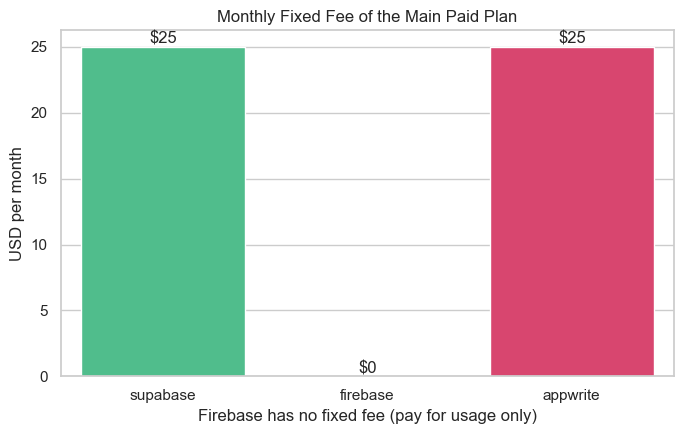

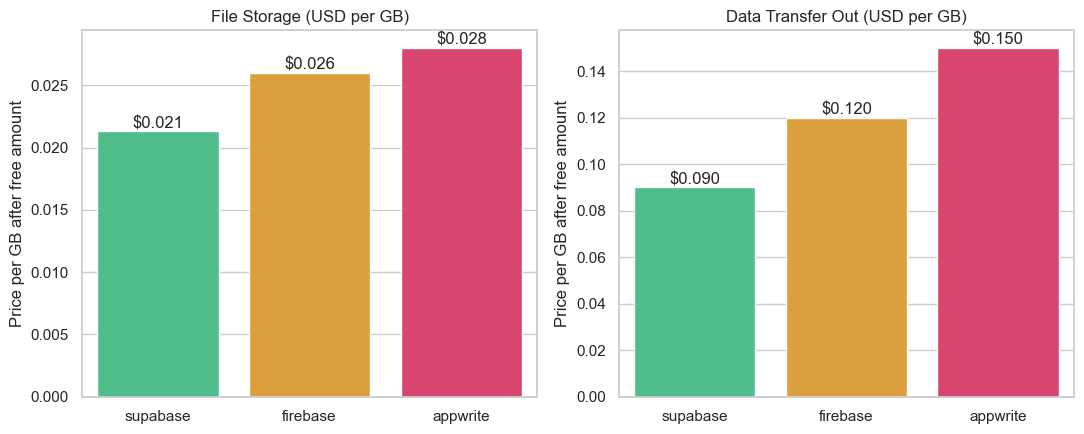

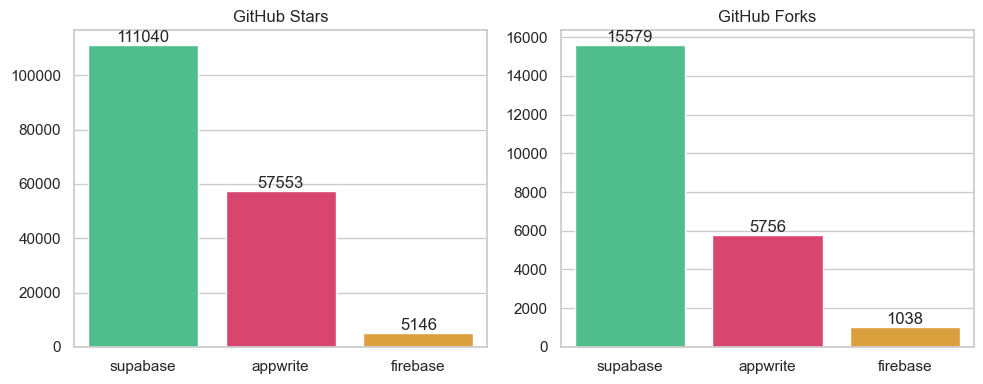

In [10]:
# Chart 1: fixed fee
paid = plans[plans["plan"].isin(["Pro", "Pay as you go (Blaze)"])]
plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=paid, x="product", y="monthly_fee_usd",
                 hue="product", palette=colors, legend=False)
for c in ax.containers:
    ax.bar_label(c, fmt="$%.0f")
ax.set_title("Monthly Fixed Fee of the Main Paid Plan")
ax.set_xlabel("Firebase has no fixed fee (pay for usage only)")
ax.set_ylabel("USD per month")
plt.tight_layout(); plt.savefig("chart_1_plan_fee.png"); plt.show()

# Chart 2: usage prices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, keyword, title in zip(axes, ["File storage", "Data transfer out"],
                              ["File Storage (USD per GB)", "Data Transfer Out (USD per GB)"]):
    d = usage[usage["item"].str.contains(keyword)]
    sns.barplot(data=d, x="product", y="price_after_free_usd", hue="product",
                palette=colors, legend=False, ax=ax)
    for c in ax.containers:
        ax.bar_label(c, fmt="$%.3f")
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("Price per GB after free amount")
plt.tight_layout(); plt.savefig("chart_2_usage_prices.png"); plt.show()

# Chart 3: GitHub
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(axes, ["stars", "forks"], ["GitHub Stars", "GitHub Forks"]):
    sns.barplot(data=df_github, x="product", y=col, hue="product",
                palette=colors, legend=False, ax=ax)
    for c in ax.containers:
        ax.bar_label(c, fmt="%d")
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.savefig("chart_3_github.png"); plt.show()

**Chart 1:** Supabase and Appwrite both start at $25 per month. Firebase shows $0 because it has no fixed fee and charges for usage only.

**Chart 2:** Supabase has the lowest price per GB for file storage ($0.021) and data transfer ($0.09), then Firebase, then Appwrite.

**Chart 3:** Supabase has the most GitHub stars and forks, then Appwrite. Firebase's numbers are for its JavaScript library only, so they are not a fair comparin.n.

 ## Cost scenarios and cost curve

product,appwrite,firebase,supabase
scenario,,,
Small app,25.0,8.79,25.00
Medium app,34.8,129.27,101.02
Large app,526.8,648.27,492.97


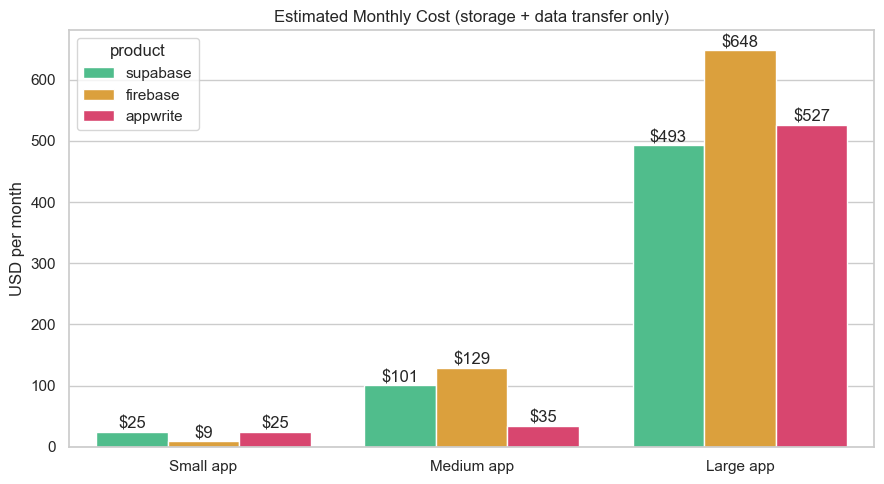

In [11]:
def monthly_cost(product, storage_gb, transfer_gb):
    if product == "supabase":      # Pro plan
        return 25 + max(storage_gb - 100, 0) * 0.0213 + max(transfer_gb - 250, 0) * 0.09
    if product == "appwrite":      # Pro plan
        return 25 + max(storage_gb - 150, 0) * 0.028 + max(transfer_gb - 2000, 0) * 0.15
    if product == "firebase":      # Blaze plan, no fixed fee
        return 0 + max(storage_gb - 5, 0) * 0.026 + max(transfer_gb - 30, 0) * 0.12

scenarios = {                      # (GB stored, GB downloaded per month)
    "Small app": (20, 100),
    "Medium app": (500, 1000),
    "Large app": (2000, 5000),
}

rows = []
for name, (stor, trans) in scenarios.items():
    for p in ["supabase", "firebase", "appwrite"]:
        rows.append([name, p, round(monthly_cost(p, stor, trans), 2)])
df_cost = pd.DataFrame(rows, columns=["scenario", "product", "monthly_cost_usd"])

display(df_cost.pivot(index="scenario", columns="product", values="monthly_cost_usd")
        .loc[list(scenarios)])

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=df_cost, x="scenario", y="monthly_cost_usd", hue="product", palette=colors)
for c in ax.containers:
    ax.bar_label(c, fmt="$%.0f")
ax.set_title("Estimated Monthly Cost (storage + data transfer only)")
ax.set_xlabel(""); ax.set_ylabel("USD per month")
plt.tight_layout(); plt.savefig("chart_4_cost_scenarios.png"); plt.show()

df_cost.to_csv("cost_scenarios.csv", index=False)

 Estimated monthly cost for three example app sizes (storage and data transfer only). Firebase is cheapest for the small app, Appwrite for the medium app, and Supabase for the large app. The app sizes are examples I chose.

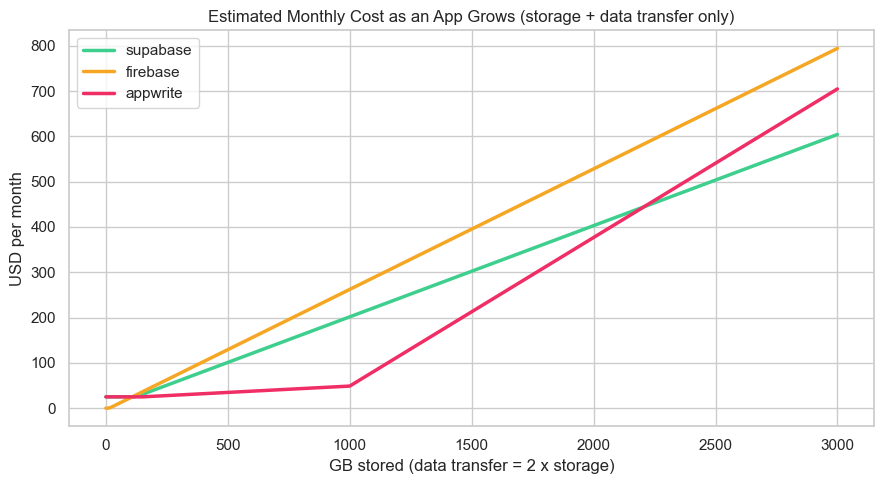

Cheapest platform changes at these storage sizes (GB):
0       firebase
110     appwrite
2210    supabase
dtype: object


In [12]:
import numpy as np

# Assumption: the app downloads 2 GB of data for every 1 GB it stores
storage_range = np.arange(0, 3001, 10)
products = ["supabase", "firebase", "appwrite"]

curve = pd.DataFrame(
    {p: [monthly_cost(p, s, 2 * s) for s in storage_range] for p in products},
    index=storage_range,
)

plt.figure(figsize=(9, 5))
for p in products:
    plt.plot(curve.index, curve[p], label=p, color=colors[p], linewidth=2.5)
plt.title("Estimated Monthly Cost as an App Grows (storage + data transfer only)")
plt.xlabel("GB stored (data transfer = 2 x storage)")
plt.ylabel("USD per month")
plt.legend()
plt.tight_layout()
plt.savefig("chart_6_cost_curve.png")
plt.show()

# Where does the cheapest platform change?
cheapest = curve.idxmin(axis=1)
changes = cheapest[cheapest != cheapest.shift()]
print("Cheapest platform changes at these storage sizes (GB):")
print(changes)

Firebase is cheapest below about 110 GB stored, Appwrite from about 110 to 2,200 GB, and Supabase above about 2,200 GB (data transfer is assumed to be 2 x storage).

In [13]:
for name, text in pages_text.items():
    with open(f"{name}_pricing_page_text.txt", "w", encoding="utf-8") as f:
        f.write(text)
    print(name, "saved,", len(text), "characters")

supabase saved, 17703 characters
appwrite saved, 3267 characters
firebase saved, 21401 characters


## Offerings: included resources, features and free plans

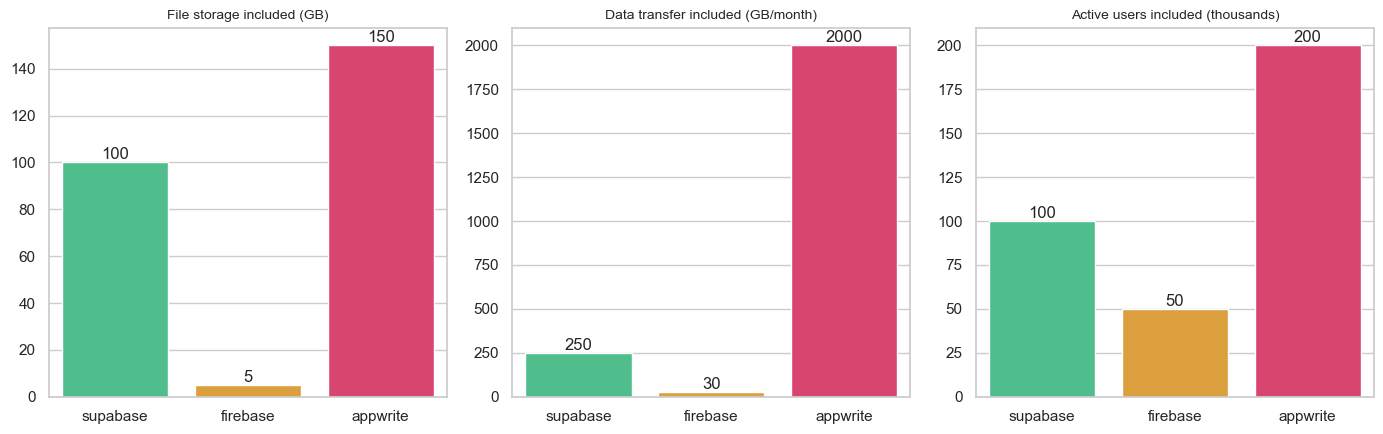

In [14]:
included = pd.DataFrame({
    "product": ["supabase", "firebase", "appwrite"],
    "File storage included (GB)": [100, 5, 150],
    "Data transfer included (GB/month)": [250, 30, 2000],
    "Active users included (thousands)": [100, 50, 200],
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col in zip(axes, included.columns[1:]):
    sns.barplot(data=included, x="product", y=col, hue="product",
                palette=colors, legend=False, ax=ax)
    for c in ax.containers:
        ax.bar_label(c, fmt="%g")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.savefig("chart_5_included_resources.png")
plt.show()

 Appwrite's Pro plan includes the most storage, data transfer and active users. Firebase's 30 GB of data transfer is an approximation of 1 GB per day.

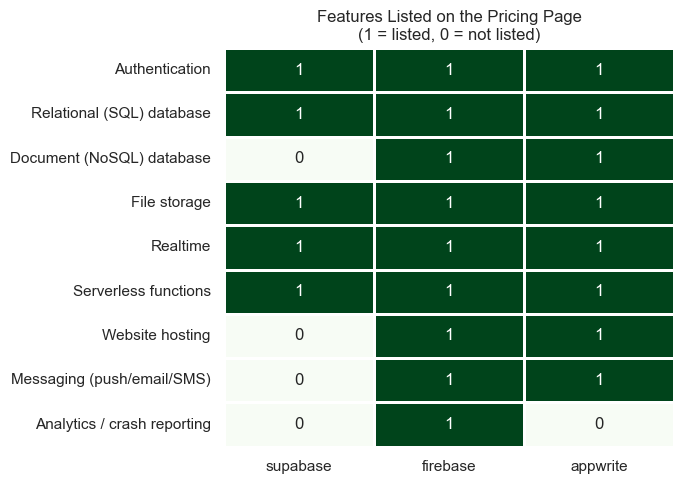

firebase    9
appwrite    8
supabase    5
dtype: int64


In [15]:
features = pd.DataFrame({
    "Authentication":                [1, 1, 1],
    "Relational (SQL) database":     [1, 1, 1],
    "Document (NoSQL) database":     [0, 1, 1],
    "File storage":                  [1, 1, 1],
    "Realtime":                      [1, 1, 1],
    "Serverless functions":          [1, 1, 1],
    "Website hosting":               [0, 1, 1],
    "Messaging (push/email/SMS)":    [0, 1, 1],
    "Analytics / crash reporting":   [0, 1, 0],
}, index=["supabase", "firebase", "appwrite"]).T

plt.figure(figsize=(7, 5))
sns.heatmap(features, annot=True, cmap="Greens", cbar=False,
            linewidths=1, linecolor="white", fmt="d")
plt.title("Features Listed on the Pricing Page\n(1 = listed, 0 = not listed)")
plt.ylabel(""); plt.xlabel("")
plt.tight_layout()
plt.savefig("chart_7_features.png")
plt.show()

print(features.sum().sort_values(ascending=False))

A 1 means the feature is listed on the pricing page. A 0 means it is not listed there, not that the product lacks it.

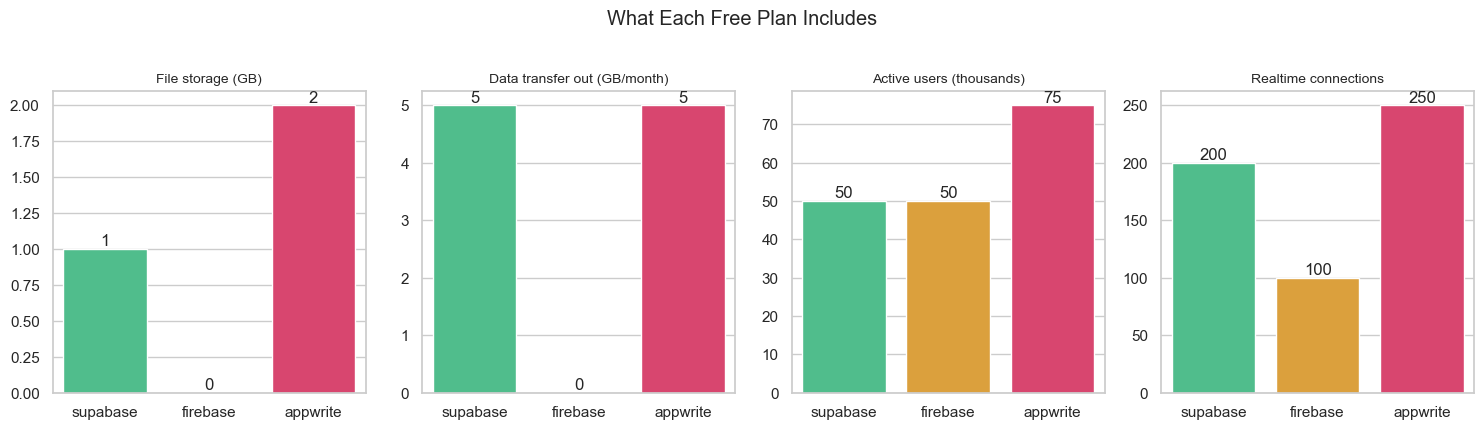

,product,projects,inactivity,other limits
0,supabase,2 active projects,Paused after 1 week of inactivity,500 MB database
1,firebase,No project limit shown,No pausing shown,Cloud Storage and Cloud Functions not available; Hosting has 10 GB
2,appwrite,2 projects (shared resources),Paused after 1 week of inactivity,"1 database, 1 bucket and 2 functions per project"


In [16]:
pd.set_option("display.max_colwidth", None)
free = pd.DataFrame({
    "File storage (GB)":                [1, 0, 2],
    "Data transfer out (GB/month)":     [5, 0, 5],
    "Active users (thousands)":         [50, 50, 75],
    "Realtime connections":             [200, 100, 250],
}, index=["supabase", "firebase", "appwrite"])

fig, axes = plt.subplots(1, 4, figsize=(15, 4.2))
for ax, col in zip(axes, free.columns):
    sns.barplot(x=free.index, y=free[col], hue=free.index,
                palette=colors, legend=False, ax=ax)
    for c in ax.containers:
        ax.bar_label(c, fmt="%g")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("What Each Free Plan Includes", y=1.02)
plt.tight_layout()
plt.savefig("chart_8_free_plans.png", bbox_inches="tight")
plt.show()

free_notes = pd.DataFrame([
    ["supabase", "2 active projects", "Paused after 1 week of inactivity", "500 MB database"],
    ["firebase", "No project limit shown", "No pausing shown", "Cloud Storage and Cloud Functions not available; Hosting has 10 GB"],
    ["appwrite", "2 projects (shared resources)", "Paused after 1 week of inactivity", "1 database, 1 bucket and 2 functions per project"],
], columns=["product", "projects", "inactivity", "other limits"])
display(free_notes)

Appwrite has the most generous free plan. Firebase's free plan has no Cloud Storage (file storage), but it includes other storage, such as Firestore, Realtime Database and Hosting, which are not shown here.

# Task Description and Summary

## Task
**Objective:** Analyze competitors' services and pricing to get market insights.

**Deliverables:**
- Collect data from competitor websites (by scraping or APIs)
- Visualize differences in pricing, offerings and user engagement
- Use the results for data-driven decisions about pricing strategy

## Scope (assumption)
The task did not name an industry or competitors, and I had no supervisor to ask. I chose three backend platforms for app developers: **Supabase, Appwrite and Firebase**.

## Data sources and methods
- **User engagement:** GitHub stars, forks and open issues, collected with the public GitHub API (no key needed).
- **Pricing and offerings:** I checked robots.txt first, then downloaded each pricing page with requests and BeautifulSoup and searched its text for prices. I confirmed the plan names, prices and limits by reading the pages in the browser and entered them into tables. Appwrite's plan details (Free and Pro) were read from its page in the browser, because the downloaded page text only contained its database prices.
- All data was collected on **2 October 2026**. Each table has source and date columns.

## What the notebook shows
1. Fixed monthly plan fees
2. Usage prices (file storage and data transfer per GB)
3. Estimated monthly cost for small, medium and large example apps
4. A cost curve showing where the cheapest platform changes
5. What each paid plan and free plan includes
6. A feature comparison from the pricing pages
7. GitHub stars and forks as a measure of developer interest

## Main findings
- **Pricing models differ.** Supabase and Appwrite start at $25 per month. Firebase has no fixed fee and charges for usage only.
- **The cheapest platform depends on app size** (storage and data transfer only, with data transfer set to 2 x storage): Firebase is cheapest below about 110 GB stored, Appwrite from about 110 to 2,200 GB, and Supabase above about 2,200 GB.
-  **Appwrite includes the most** storage, data transfer and active users in its Pro plan. On the free plan it also has the most storage and users, and ties with Supabase on data transfer (5 GB).
- **Supabase has the most developer interest** (about 111,000 GitHub stars), followed by Appwrite (about 57,500).

## Pricing recommendations (for a new platform entering this market)
1. Offer a free plan, because all three competitors do.
2. Start the first paid plan near $25 per month, as Supabase and Appwrite do.
3. Use a fixed fee with generous included usage, because it makes bills predictable.
4. Include a lot of data transfer, because it was the biggest cost in the larger scenarios.
5. Keep the price for extra usage low to keep heavy users.

## Limitations and assumptions
- Only three competitors were compared.
- Costs include storage and data transfer only. Database, compute and extra user costs are not included.
- The app sizes and the 2 x storage transfer ratio are my own examples, not real customer data.
- Firebase's free transfer was approximated as 30 GB per month (1 GB per day).
- Firebase storage prices are for older bucket types.
- Appwrite's $25 and Supabase's Team $599 are "from" prices.
- Firebase's GitHub numbers are for its JavaScript library only, so they are not a fair comparison.
- A feature marked 0 means it is not listed on the pricing page, not that the product lacks it.
- Prices change often and may be different after 2 October 2026.